<a href="https://colab.research.google.com/github/AnnaEzGa/Pr-ctica_3/blob/main/Pr%C3%A1ctica_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#PRÀCTICA 3

# 1. LIBRERÍAS

sisl es una librería de Python que NO hace el cálculo DFT, si no que lo que hace es leer y analizar los resultados de SIESTA. De este modo, con sisl puedes:

- leer estructuras hechas con SISTA (.fdf, .XV)
- leer energías de orbitales resueltas con SISTA(.EIG)
- generar .cube
- visualizar moléculas
- analizar HOMO/LUMO

Que es un poco lo que haremos con esta práctica.

No està tienes instalado el paquete sisl en el entorno donde estás ejecutando Python, por eso, antes de comenzar, se tiene que instalar. En Colab tendrás que instalar sisl cada vez que abras el notebook (porque el entorno se reinicia).

In [2]:
!pip install --upgrade sisl netCDF4 plotly scikit-image pathos nodify # Para instalar la librería básica que vamos a usar (sisl).

In [3]:
pip install "sisl[viz]" # Instala lo necesario para visualizar estructuras.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 27.1 MB/s eta 0:00:00


Ahora cargamos las librerías:

In [4]:
from sisl import *
import numpy as np
import matplotlib.pyplot as plt

Hay que subir al entorno de colab la carpeta con la que vamos a trabajar:

In [6]:
from google.colab import files
uploaded = files.upload()  # seleccionas C60_coords.fdf y otros archivos necesarios

Saving 0_NORMAL_EXIT to 0_NORMAL_EXIT (1)
Saving BASIS_ENTHALPY to BASIS_ENTHALPY (1)
Saving BASIS_HARRIS_ENTHALPY to BASIS_HARRIS_ENTHALPY (1)
Saving C.ion to C (1).ion
Saving C.ion.nc to C.ion (1).nc
Saving C.psf to C (1).psf
Saving C60.alloc to C60 (1).alloc
Saving C60.BASIS_ENTHALPY to C60 (1).BASIS_ENTHALPY
Saving C60.bib to C60 (1).bib
Saving C60.BONDS to C60 (1).BONDS
Saving C60.BONDS_FINAL to C60 (1).BONDS_FINAL
Saving C60.DM to C60 (1).DM
Saving C60.EIG to C60 (1).EIG
Saving C60.FA to C60 (1).FA
Saving C60.HSX to C60 (1).HSX
Saving C60.KP to C60 (1).KP
Saving C60.ORB_INDX to C60 (1).ORB_INDX
Saving C60.STRUCT_OUT to C60 (1).STRUCT_OUT
Saving C60.XV to C60 (1).XV
Saving C60.xyz to C60 (1).xyz
Saving C60_coords.fdf to C60_coords (1).fdf
Saving CLOCK to CLOCK (1)
Saving fdf.20260312T140806.991.log to fdf.20260312T140806.991 (1).log
Saving FORCE_STRESS to FORCE_STRESS (1)
Saving MESSAGES to MESSAGES (1)
Saving OUTVARS.yml to OUTVARS (1).yml
Saving PARALLEL_DIST to PARALLEL_DIST (1

# 2. VISUALIZACIÓN DE LA ESTRUCTURA:

In [7]:
system = Geometry.read("./C60_coords.fdf") # El documento de cC60_coords.fdf contiene la información de qué átomos hay en el sistema y sus coordenadas, posiciones, en el espacio. Por lo tanto, con este comando de "system = Geometry.read("./C60_coords.fdf")" se está presentando el sistema descrito en este docuemnto, y se está diciendo que se lea la geometría de este (átomos y posiciones de estos), para poder representarlo luego y tal.

In [8]:
system.plot() # Para poder visualizar el sistema en 3D, el cual, está como dentro de una caja.

In [9]:
system.plot(axes="xy") # Para visualizar el sustema en 2d, el cual está dentro de una caja.

# 3. ANÁLISIS DE LOS RESULTADOS CON SIESTA


SIESTA es un programa de simulación que sirve para hacer cálculos de estructura electrónica con DFT de:

- moléculas
- materiales
- sistemas nanométricos

Es decir, SIESTA hace el cálculo físico (calcula energías, orbitales, densidad electrónica, HOMO, LUMO, etc) y los resultados se guardan en archivos como:
- EIG
- XV
- cube
- out
- fdf

In [10]:
fdf = get_sile("RUN.fdf") # Para abrir el archivo RUN.fdf y llamarlo fdf, para luego usarlo más adelante en cálculos mediante siesta y tal.

In [11]:
H = fdf.read_hamiltonian() # Con esto decimos que del archivo RUN.fdf pues que lea, coja y calcule el Hamiltoniando del sistema. Este Hamiltoniando contiene coordenadas de los átomos y los orbitales de los átomos.

In [12]:
print(H) # Muestra el Hamiltoniano que se ha leído.

Hamiltonian{non-zero: 418830, orthogonal: False,
 Spin{unpolarized},
 Geometry{na: 60, no: 780,
  Atoms{species: 1,
   Atom{C, Z: 6, mass(au): 12.01100, maxR: 3.30951,
    AtomicOrbital{2sZ1, q0: 2.0, SphericalOrbital{l: 0, R: 2.6548991702149065, q0: 2.0}},
    AtomicOrbital{2sZ2, q0: 0.0, SphericalOrbital{l: 0, R: 1.6858398488354462, q0: 0.0}},
    AtomicOrbital{2pyZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260040147, q0: 2.0}},
    AtomicOrbital{2pzZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260040147, q0: 2.0}},
    AtomicOrbital{2pxZ1, q0: 0.6666666666666666, SphericalOrbital{l: 1, R: 3.309510260040147, q0: 2.0}},
    AtomicOrbital{2pyZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003493, q0: 0.0}},
    AtomicOrbital{2pzZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003493, q0: 0.0}},
    AtomicOrbital{2pxZ2, q0: 0.0, SphericalOrbital{l: 1, R: 2.106206766003493, q0: 0.0}},
    AtomicOrbital{3dxyZ1P, q0: 0.0, SphericalOrbital{l: 2, R: 3.309

3.1. MOSTRAR DATOS EMPLEADOS EN EL CÁLCULO:

Antes de analizar la diagonalización de H, podemos mostrar la geometría del sistema y el conjunto de base empleado. Es decir, que vamos a observar los orbitales.  

In [13]:
system = H.geometry # Con esto decimos que coja la geometría que hay en el Hamiltoniano, y veremos que la geometría del hamiltoniano NO ha cambiado.

In [14]:
system.plot(axes="xy")

In [15]:
# FUNCTION PLOT ORBITALS, para representar y poder ver más gra´ficamente los distintos orbitales del sistema.
def plot_atom(atom):
    no = len(atom) # number of orbitals
    nx = no // 4
    ny = no // nx
    if nx * ny < no:
        nx += 1
    fig, axs = plt.subplots(nx, ny, figsize=(20, 5*nx))
    fig.suptitle('Atom: {}'.format(atom.symbol), fontsize=14)
    def my_plot(i, orb):
            grid = orb.toGrid(atom=atom)
            # Also write to a cube file
            grid.write('{}_{}.cube'.format(atom.symbol, orb.name()))
            c, r = i // 4, (i - 4) % 4
            if nx == 1:
                ax = axs[r]
            else:
                ax = axs[c][r]
            ax.imshow(grid.grid[:, :, grid.shape[2] // 2])
            ax.set_title(r'${}$'.format(orb.name(True)))
            ax.set_xlabel(r'$x$ [Ang]')
            ax.set_ylabel(r'$y$ [Ang]')
    i = 0
    for orb in atom:
            my_plot(i, orb)
            i += 1
    if i < nx * ny:
            # This removes the empty plots
            for j in range(i, nx * ny):
                c, r = j // 4, (j - 4) % 4
                if nx == 1:
                    ax = axs[r]
                else:
                    ax = axs[c][r]
                fig.delaxes(ax)
            plt.draw()

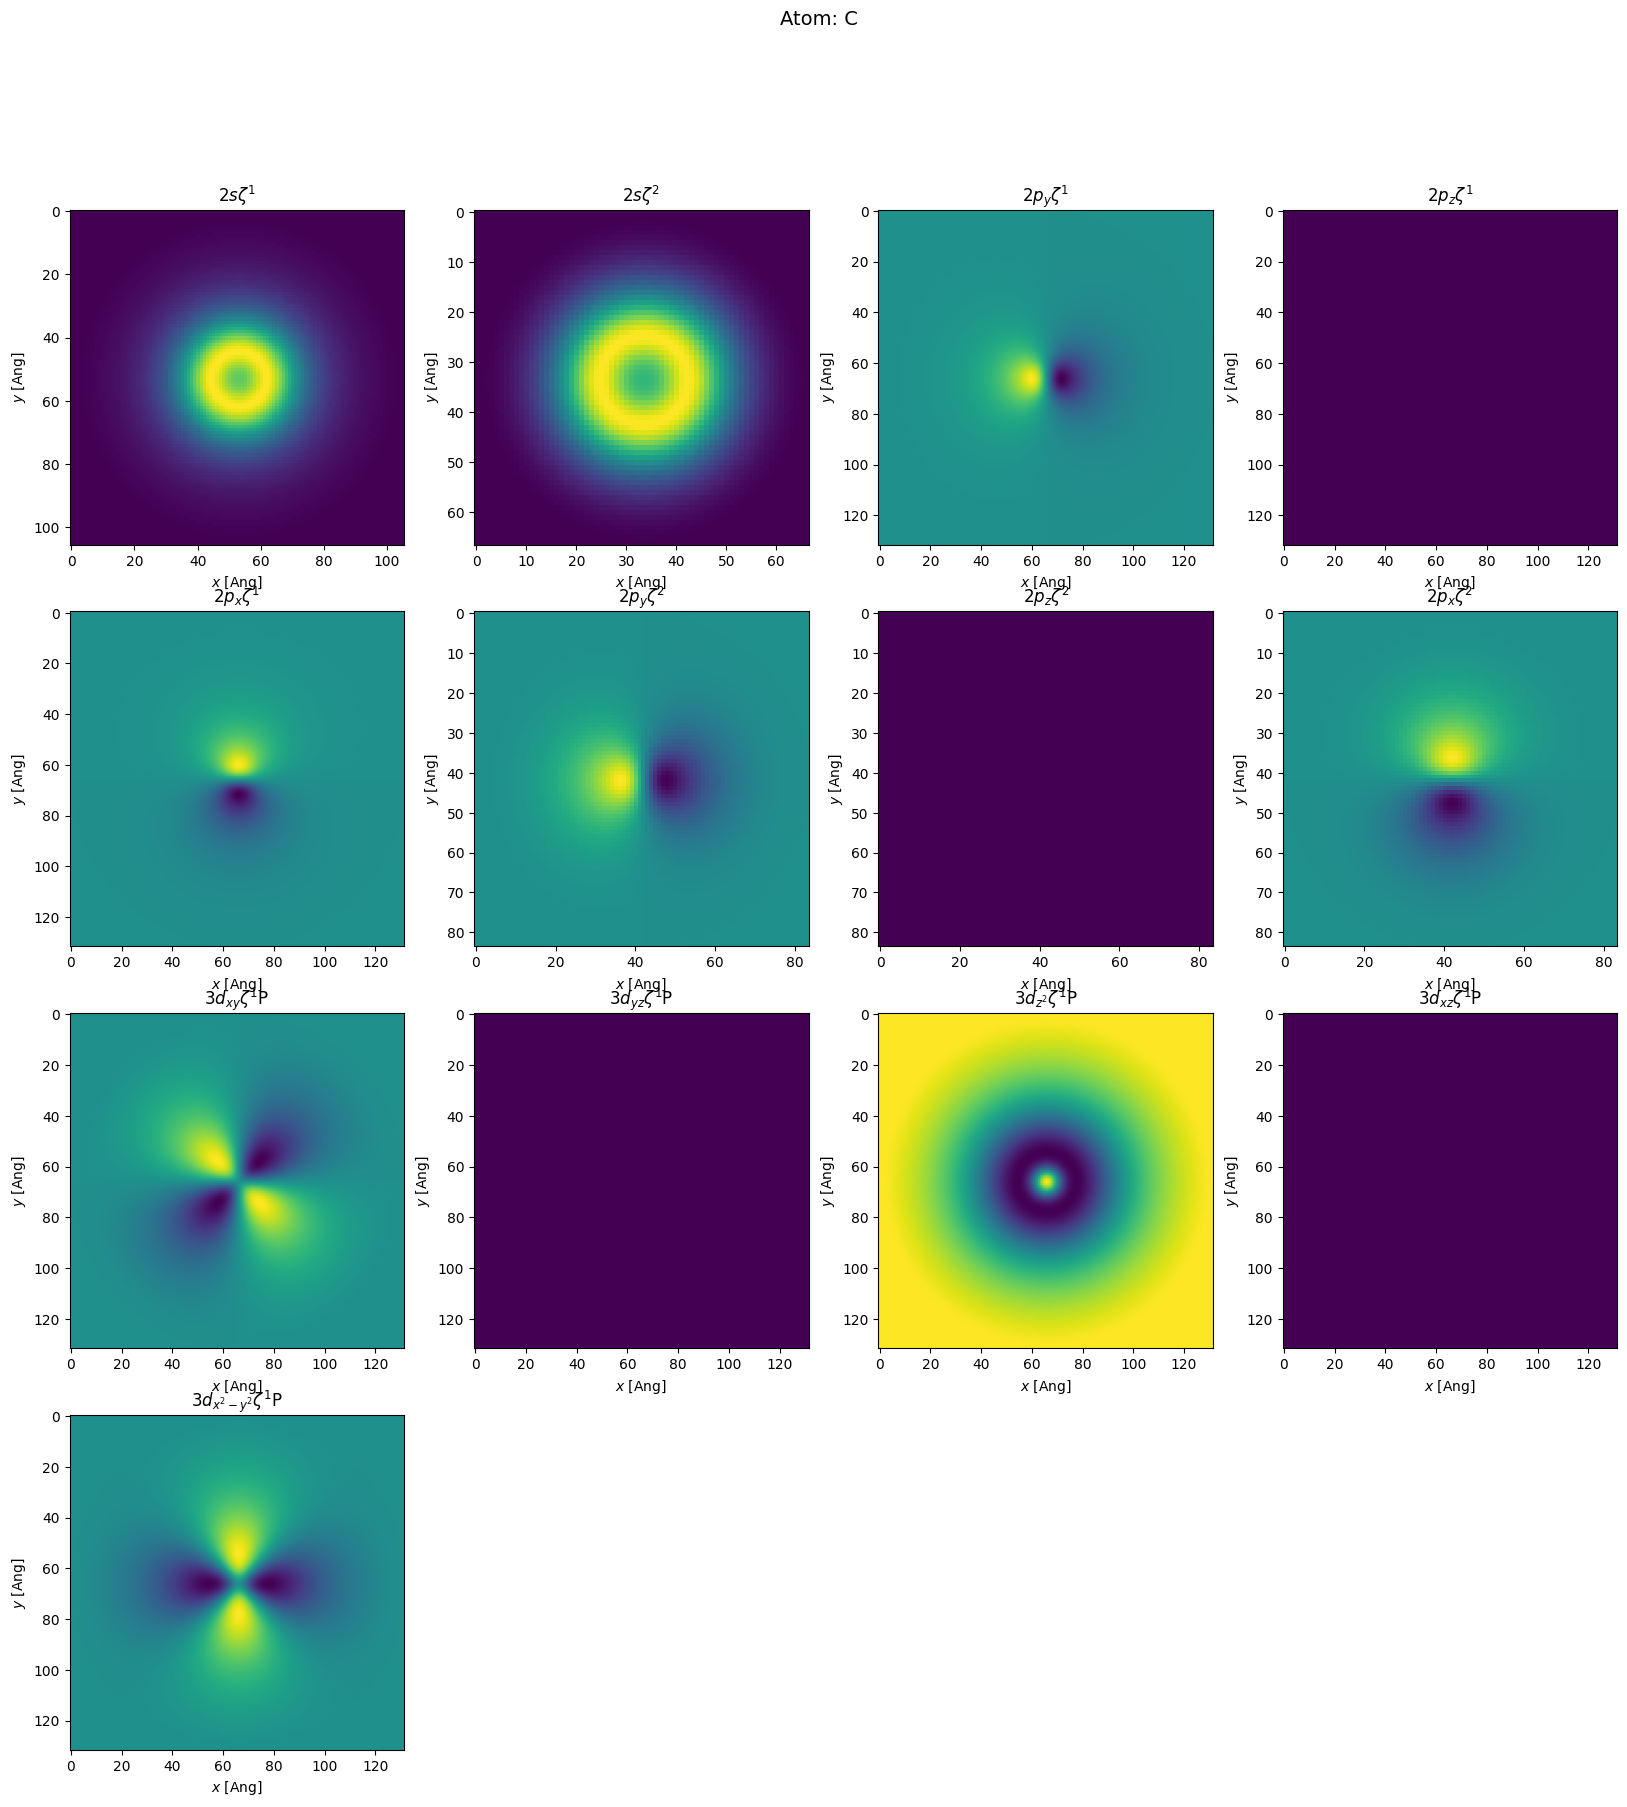

In [16]:
# Para mostrar los gráficos. IMPORTANTEEEEEEEE!!!!!! Aquí estamos representando los orbitales ATÓMICOS (los de los átomos, NO los orbitales moleculares, es decir, los que son de la molécula, y que se obtienen resolviendo el hamiltoniano)
plot_atom(system.atoms[0]) # Primer carbono
plt.show()

# 4. ESTADOS PRÓPIOS

In [17]:
es=H.eigenstate() # Para encontrar los estados própios (funciones y energías própias).

In [18]:
es.eig # Para dar mosrtrar valores de las energías própias.

array([-17.01909909, -16.63281527, -16.62564271, -16.62383587,
       -15.89340179, -15.88639517, -15.88068881, -15.8776722 ,
       -15.8708432 , -15.19457864, -15.18868034, -15.17974138,
       -14.24497093, -14.23341232, -14.22753644, -14.21083371,
       -13.33928826, -13.32796037, -13.32324472, -13.31057918,
       -13.30088033, -12.94195192, -12.93095136, -12.91706883,
       -12.90552439, -11.9572821 , -11.95229564, -11.94467317,
       -11.94138594, -11.9285915 , -11.45923804, -11.44003554,
       -11.42514301, -10.13594004, -10.11780741, -10.09172207,
        -9.9851326 ,  -9.97550938,  -9.97176637,  -9.4931778 ,
        -9.49098625,  -9.48052183,  -9.460764  ,  -9.45491422,
        -8.14407292,  -7.88806172,  -7.87934555,  -7.87315489,
        -7.86185733,  -7.84645231,  -7.83830983,  -7.8248685 ,
        -7.81958152,  -7.79830919,  -6.80125579,  -6.78876362,
        -6.78518372,  -6.01948995,  -6.00715404,  -6.00667596,
        -5.99584281,  -5.98680315,  -5.98054121,  -5.97

In [19]:
idx_lumo = (es.eig > 0).nonzero()[0][0] # Truco para obtener el LUMO
idx_homo = idx_lumo-1 # Truco para obtener el HOMO

In [20]:
print(idx_lumo) # Ver eel valor de la energía del LUMO

120


In [21]:
# Para obteneer los valores de las energías en eV
print("HOMO E=",es.eig[idx_homo]," eV")
print("LUMO E=",es.eig[idx_lumo]," eV")

HOMO E= -0.5370867161013628  eV
LUMO E= 0.5207515730175892  eV


# 5. EXPORTACIÓN DE FUNCIONES DE ONDA PARA GRÁFICOS 3D

Para exportar los orbitales moleculares y las funciones de onda. Es decir, ahora SÍ que vamos a representar las funciones de onda obtenidaar al solucionar el hamiltoniano (los orbitales moleculares, los orbitales efectivos).

No osbtante esto, para poder representar los orbitales, hayq ue tener en cuenta que la función de onda del orbital molecular (ψ(r)) es continua en el espacio, pero el ordenador solo puede manejar valores discretos. Por eso se define un grid (un sector, malla, 3D) dentro de la caja de simulación, el cual se trata de una red de puntos separados una distancia fija (por ejemplo 0.2 Å). En cada punto se calcula el valor de ψ(x,y,z) o |ψ(x,y,z)|² para poder visualizarlo.

En cuanto a los orbitales moleculares, hay que saber que uno de estos no se calcula directamente en el espacio, sino como combinación de orbitales atómicos (representados anteriormeente). Por lo tanto, sabiendo que al resolver el Hamiltoniano, lo que se obtienen son
energías y los coeficientes con los que se combinan cada orbital atómico para dar un orbital molecular, pues el grid es solo el lugar donde evalúas esa combinación en el espacio para poder dibujarla, es decir, para poder obtener una imagen.

In [23]:
system.lattice.origin = [-8, -8, -8]
g = Grid(0.2, lattice=system.lattice)  # Donde 0.2 es la distáncia entre puntos del grid.

5.1. GUARDAR LOS ESTADOS NHOMO Y LUMO EN UN ARCHIVO CUBE

In [24]:
# Para guardar el HOMO.
es[idx_homo].wavefunction(g)
g.write('HOMO.cube')
print('Real space integrated wavefunction: {:.4f}'.format((np.absolute(g.grid) ** 2).sum() * g.dvolume))
g.fill(0) # reset the grid values to 0

info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


Real space integrated wavefunction: 1.0000


In [25]:
# Para guardar el LUMO.
es[idx_lumo].wavefunction(g)
g.write('LUMO.cube')
print('Real space integrated wavefunction: {:.4f}'.format((np.absolute(g.grid) ** 2).sum() * g.dvolume))
g.fill(0) # reset the grid values to 0

info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


Real space integrated wavefunction: 1.0000


5.2. GUARDAR LA DENSIDAD ELECTRÓNICA

In [26]:
g2 = Grid(0.2, lattice=system.lattice)

In [27]:
es[idx_lumo].wavefunction(g)
g2=g*g.grid.conj()
g2.write('LUMOdens.cube')
g2.fill(0) # reset the grid values to 0

info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


Guardar la densidad electrónica incluyendo un rango de estados.

In [28]:
es[idx_lumo].wavefunction(g)
g2=g*g.grid.conj()
g2.write('LUMOdens.cube')
g2.fill(0) # reset the grid values to 0

info:0: SislInfo: wavefunction: coordinates may be outside your primary unit-cell. Translating all into the primary unit cell could disable this information


In [29]:
!ls

 0_NORMAL_EXIT		      C60.BONDS_FINAL
'0_NORMAL_EXIT (1)'	     'C60_coords (1).fdf'
 BASIS_ENTHALPY		      C60_coords.fdf
'BASIS_ENTHALPY (1)'	      C60.DM
 BASIS_HARRIS_ENTHALPY	      C60.EIG
'BASIS_HARRIS_ENTHALPY (1)'   C60.FA
'C (1).ion'		      C60.HSX
'C (1).psf'		      C60.KP
 C_2pxZ1.cube		      C60.ORB_INDX
 C_2pxZ2.cube		      C60.STRUCT_OUT
 C_2pyZ1.cube		      C60.XV
 C_2pyZ2.cube		      C60.xyz
 C_2pzZ1.cube		      C.ion
 C_2pzZ2.cube		     'C.ion (1).nc'
 C_2sZ1.cube		      C.ion.nc
 C_2sZ2.cube		      CLOCK
 C_3dx2-y2Z1P.cube	     'CLOCK (1)'
 C_3dxyZ1P.cube		      C.psf
 C_3dxzZ1P.cube		     'fdf.20260312T140806.991 (1).log'
 C_3dyzZ1P.cube		      fdf.20260312T140806.991.log
 C_3dz2Z1P.cube		      FORCE_STRESS
'C60 (1).alloc'		     'FORCE_STRESS (1)'
'C60 (1).BASIS_ENTHALPY'      HOMO.cube
'C60 (1).bib'		      LUMO.cube
'C60 (1).BONDS'		      LUMOdens.cube
'C60 (1).BONDS_FINAL'	      MESSAGES
'C60 (1).DM'		     'MESSAGES (1)'
'C60 (1).EIG'		     'OUTVARS (1).yml'
'C60 (1

In [30]:
from google.colab import files
files.download('HOMO.cube')
files.download('LUMO.cube')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>